# 1. Exploratory Data Analysis
Questo notebook scarica i dataset per YOLO e SAM e mostra un'analisi grafica preliminare dei dati.

In [1]:
import subprocess
print('⏳ Installazione librerie (può richiedere qualche secondo)...')
subprocess.run(['pip', 'install', '-q', 'kaggle', 'opencv-python-headless', 'tqdm', 'matplotlib', 'numpy<2'], check=True)
print('✅ Librerie installate')


⏳ Installazione librerie (può richiedere qualche secondo)...
✅ Librerie installate


In [2]:
import os, json, base64, zlib, cv2, numpy as np, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
print('✅ Moduli importati con successo!')

✅ Moduli importati con successo!


In [3]:
# ── Setup Cartelle ─────────────────────────────────────────────────────────────
BASE = Path('/teamspace/studios/this_studio/project-sbs')
DATASETS = BASE / 'datasets'
RAW_YOLO = DATASETS / 'dati_grezzi_yolo'
RAW_SAM  = DATASETS / 'dati_grezzi_sam'

for d in [RAW_YOLO, RAW_SAM]:
    d.mkdir(parents=True, exist_ok=True)
print('✅ Cartelle create')

✅ Cartelle create


In [4]:
# ── Kaggle Auth ─────────────────────────────────────────────────────────────
def load_kaggle_creds():
    uname = os.getenv('KAGGLE_USERNAME')
    key = os.getenv('KAGGLE_KEY')
    if uname and key: return uname, key
    paths = [Path.cwd() / 'kaggle.json', BASE / 'kaggle.json', Path.home() / '.kaggle/kaggle.json']
    for p in paths:
        if p.exists():
            creds = json.loads(p.read_text())
            return creds['username'], creds['key']
    raise ValueError('❌ kaggle.json non trovato')

uname, key = load_kaggle_creds()
os.environ['KAGGLE_USERNAME'] = uname
os.environ['KAGGLE_KEY'] = key
print(f'✅ Kaggle auth OK: {uname}')

✅ Kaggle auth OK: diegoscirocco


In [5]:
# ── Download Datasets ──────────────────────────────────────────────
DATASET_SLUG_YOLO = 'isaienkov/football-advertising-banners-detection'
DATASET_SLUG_SAM = 'swagatajana/football-match-adboards-mask-dataset'

if len(list(RAW_YOLO.rglob('*.png')) + list(RAW_YOLO.rglob('*.jpg'))) > 100:
    print('✅ Dataset YOLO già scaricato.')
else:
    print('📥 Download dataset YOLO...')
    subprocess.run(['kaggle', 'datasets', 'download', '-d', DATASET_SLUG_YOLO, '-p', str(RAW_YOLO), '--unzip'], check=True)

if len(list(RAW_SAM.rglob('*.png')) + list(RAW_SAM.rglob('*.jpg'))) > 50:
    print('✅ Dataset SAM già scaricato.')
else:
    print('📥 Download dataset SAM...')
    subprocess.run(['kaggle', 'datasets', 'download', '-d', DATASET_SLUG_SAM, '-p', str(RAW_SAM), '--unzip'], check=True)

✅ Dataset YOLO già scaricato.
✅ Dataset SAM già scaricato.


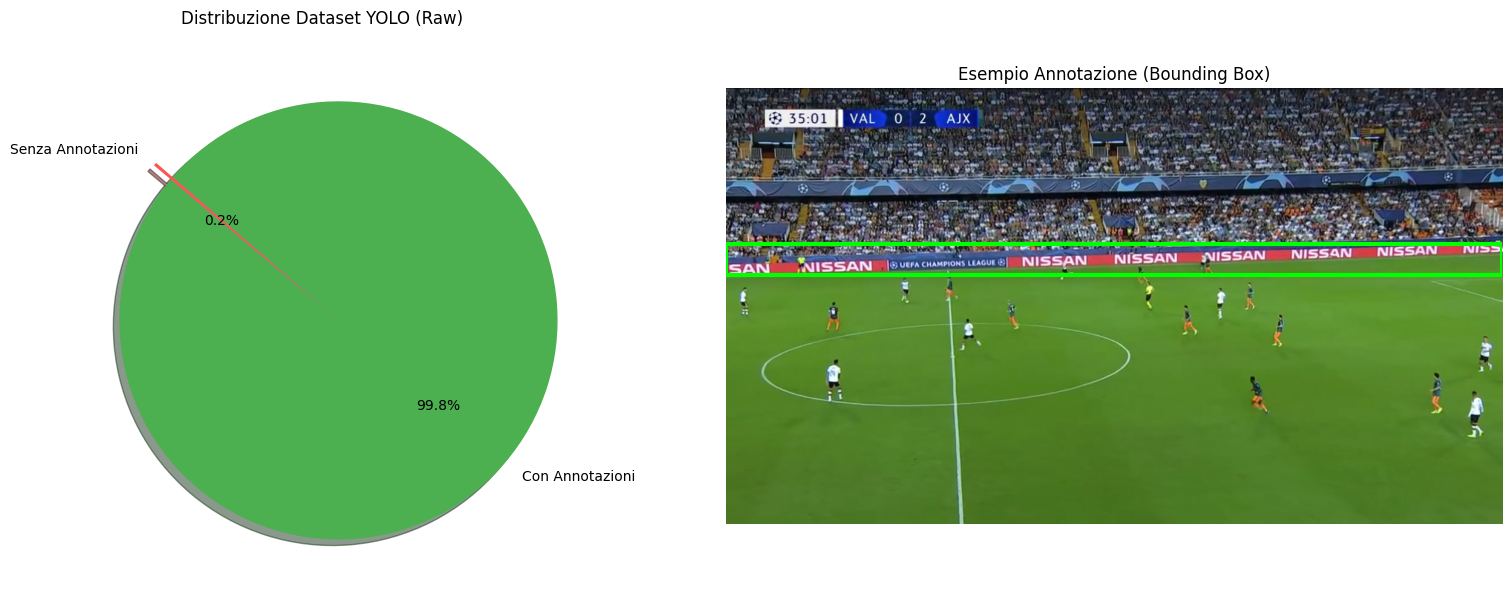

In [8]:
# ── Analisi Grafica YOLO ───────────────────────────────────────────────────
def get_banner_boxes(json_path):
    data = json.loads(json_path.read_text(encoding='utf-8'))
    iw, ih = data['size']['width'], data['size']['height']
    objects = data.get('objects', [])
    if not objects: return None
    raw_boxes = []
    for obj in objects:
        if obj.get('geometryType') != 'bitmap': continue
        bm = obj.get('bitmap', {})
        if 'data' not in bm or 'origin' not in bm: continue
        try:
            raw = zlib.decompress(base64.b64decode(bm['data']))
            arr = np.frombuffer(raw, np.uint8)
            img = cv2.imdecode(arr, cv2.IMREAD_UNCHANGED)
            if img is None: continue
            h_bm, w_bm = img.shape[0], img.shape[1]
            ox, oy = bm['origin']
            x1, y1 = max(0, ox), max(0, oy)
            x2, y2 = min(iw-1, ox+w_bm), min(ih-1, oy+h_bm)
            if x2>x1 and y2>y1: raw_boxes.append([x1,y1,x2,y2])
        except: continue
    if not raw_boxes: return None
    bands = []
    for box in sorted(raw_boxes, key=lambda b: (b[1]+b[3])/2):
        cy = (box[1]+box[3])/2
        added = False
        for band in bands:
            cy_band = (band[1]+band[3])/2
            if abs(cy-cy_band) < 0.12*ih:
                band[0] = min(band[0], box[0]); band[1] = min(band[1], box[1])
                band[2] = max(band[2], box[2]); band[3] = max(band[3], box[3])
                added = True; break
        if not added: bands.append(list(box))
    return bands

ann_dir = RAW_YOLO / 'football' / 'annotations'
img_dir = RAW_YOLO / 'football' / 'images'
all_jsons = list(ann_dir.glob('*.json'))

if all_jsons:
    # -- 1. Analisi Distribuzione per Grafico a Torta --
    valid_banners = 0
    empty_banners = 0
    for jf in all_jsons:
        data = json.loads(jf.read_text(encoding='utf-8'))
        if data.get('objects', []):
            valid_banners += 1
        else:
            empty_banners += 1
            
    # -- 2. Selezione Immagine Campione --
    sample_json = random.choice(all_jsons)
    stem = sample_json.name.replace('.png.json','').replace('.jpg.json','').replace('.json','')
    imgp = img_dir / f'{stem}.png'
    if not imgp.exists(): imgp = img_dir / f'{stem}.jpg'
    
    if imgp.exists():
        boxes = get_banner_boxes(sample_json)
        img = cv2.imread(str(imgp))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Creazione del Plot a due facce (Torta + Immagine)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Torta
        labels = ['Con Annotazioni', 'Senza Annotazioni']
        sizes = [valid_banners, empty_banners]
        axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#FF5252'], explode=[0.1, 0], shadow=True)
        axes[0].set_title('Distribuzione Dataset YOLO (Raw)')
        
        # Overlay Annotazioni
        axes[1].imshow(img)
        if boxes:
            for b in boxes:
                rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=3, edgecolor='#00FF00', facecolor='none')
                axes[1].add_patch(rect)
        axes[1].set_title('Esempio Annotazione (Bounding Box)')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

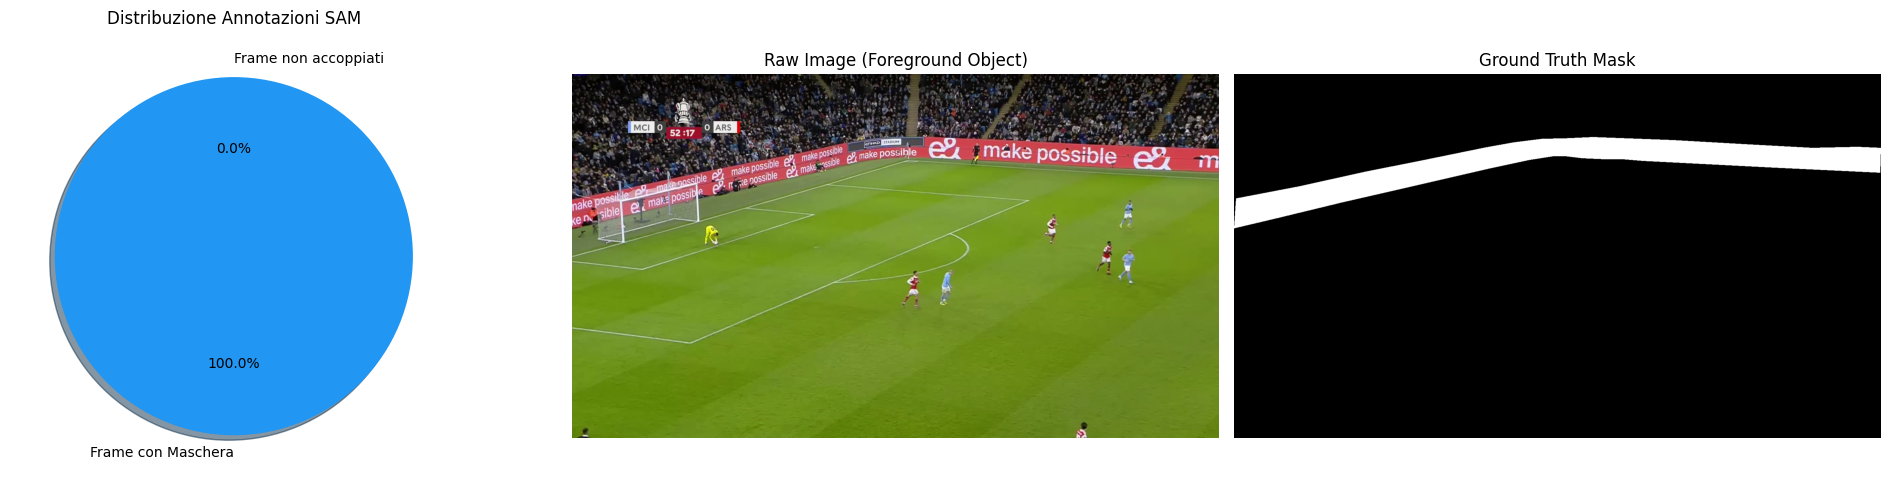

In [10]:
# ── Analisi Grafica SAM ────────────────────────────────────────────────────
mask_dir = RAW_SAM / 'Masks' / 'Masks'
img_sam_dir  = RAW_SAM / 'Tagged_Images' / 'Tagged Images'
all_masks = list(mask_dir.glob('*.png'))
all_imgs = list(img_sam_dir.glob('*.jpg')) + list(img_sam_dir.glob('*.png'))

if all_masks:
    # -- 1. Analisi Torta (Maschere vs Resto) --
    annotated = len(all_masks)
    not_annotated = max(0, len(all_imgs) - annotated)
    
    # -- 2. Campione visivo --
    sample_mask = random.choice(all_masks)
    idx = sample_mask.stem.replace('mask', '')
    imgp = img_sam_dir / f'frame{idx}.jpg'
    
    if imgp.exists():
        img = cv2.imread(str(imgp))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(sample_mask), 0)
        
        # Creazione del Plot a tre facce (Torta + Frame + Mask)
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        
        # Torta
        labels = ['Frame con Maschera', 'Frame non accoppiati']
        sizes = [annotated, not_annotated] if not_annotated > 0 else [annotated, 0.0001] # evita errori se 0
        axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#2196F3', '#FFC107'], shadow=True)
        axes[0].set_title('Distribuzione Annotazioni SAM')
        
        # Immagine e Maschera
        axes[1].imshow(img); axes[1].set_title('Raw Image (Foreground Object)'); axes[1].axis('off')
        axes[2].imshow(mask, cmap='gray'); axes[2].set_title('Ground Truth Mask'); axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()